<a href="https://colab.research.google.com/github/shanusushmita/CS4973-Applied-Multilingual-Systems/blob/main/Error_Analysis_Heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- 1. Define Labels ---
# These are the classes our model predicts and the true/gold labels.
LABELS = ['EN', 'ES', 'CS']

# --- 2. Simulate Model Predictions ---
# In a real project, these arrays would come from your model evaluation script.
# Gold (True) labels:
y_true = np.array([
    'EN', 'EN', 'EN', 'EN', 'EN', 'ES', 'ES', 'ES', 'ES', 'ES',
    'CS', 'CS', 'CS', 'CS', 'CS', 'EN', 'ES', 'CS', 'ES', 'EN',
    'CS', 'EN', 'ES', 'ES', 'CS'
])

# Predicted labels by the model:
y_pred = np.array([
    'EN', 'EN', 'ES', 'EN', 'EN', 'ES', 'ES', 'CS', 'ES', 'EN',
    'CS', 'EN', 'CS', 'ES', 'CS', 'EN', 'ES', 'ES', 'ES', 'EN',
    'CS', 'EN', 'ES', 'ES', 'CS'
])

# --- 3. Generate the Confusion Matrix ---
# The confusion_matrix function computes the matrix where C[i, j] is the count
# of observations known to be in group i and predicted to be in group j.
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

# Convert to a DataFrame for easier plotting with Seaborn and better labeling
cm_df = pd.DataFrame(cm, index=LABELS, columns=LABELS)

print("Confusion Matrix (Counts):\n", cm_df)

Confusion Matrix (Counts):
     EN  ES  CS
EN   7   1   0
ES   1   7   1
CS   1   2   5


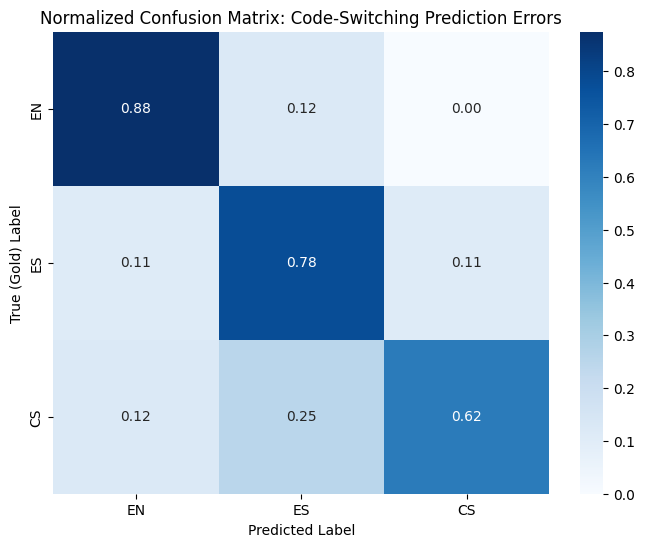

In [2]:
# --- 4. Normalize the Confusion Matrix (Optional but Recommended) ---
# Normalize by the 'true' label counts (row-wise), so that rows sum to 1.
# This shows: "Out of all tokens that *should* be 'EN', what percentage were correctly or incorrectly predicted?"
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized_df = pd.DataFrame(cm_normalized, index=LABELS, columns=LABELS)

# --- 5. Plot the Heatmap ---

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized_df,
    annot=True,              # Show the values in the cells
    fmt=".2f",               # Format the numbers to two decimal places (percentages)
    cmap="Blues",            # Use a color palette (e.g., sequential blue shades)
    cbar=True                # Display the color bar
)

# Set labels for clarity
plt.title('Normalized Confusion Matrix: Code-Switching Prediction Errors')
plt.xlabel('Predicted Label')
plt.ylabel('True (Gold) Label')
plt.show()

# NOTE: The visual is highly instructive.
# The diagonal cells (True == Predicted) show the Recall for each class.
# The off-diagonal cells show the Mislabels.